In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
jeep_df = pd.read_csv("export_jeep_pool.csv")
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times
0,0,20,2,0.42040,0.0025,400,3760|3762|3764|3768|3770|3771|3773|3774|3775|3...,13621|29174|34465|38466|42467|45242|47743|5024...,11621|22508|29175|34466|38467|42468|45243|4774...
1,1,20,3,0.58455,0.0025,400,3836|3837|3839|3841|3842|3845|3847|3848|3851|3...,12543|29140|34444|38445|42446|45229|47730|5023...,10543|22474|29141|34445|38446|42447|45230|4773...
2,2,20,3,0.71235,0.0025,380,3674|3678|3680|3681|3684|3686|3687|3692|3694|3...,28286|33932|37933|41934|44909|47410|49911|5241...,21620|28287|33933|37934|41935|44910|47411|4991...
3,3,20,2,0.29530,0.0025,380,3598|3603|3605|3607|3608|3609|3610|3612|3613|3...,28338|33963|37964|41965|44928|47429|49930|5243...,21672|28339|33964|37965|41966|44929|47430|4993...
4,4,20,3,0.67950,0.0025,380,3724|3727|3730|3732|3733|3734|3735|3736|3737|3...,28504|34063|38064|42065|44991|47492|49993|5249...,21838|28505|34064|38065|42066|44992|47493|4999...
5,5,20,2,0.32140,0.0025,380,3639|3641|3642|3644|3645|3647|3648|3652|3654|3...,28511|34067|38068|42069|44993|47494|49995|5249...,21845|28512|34068|38069|42070|44994|47495|4999...
6,6,20,3,0.65025,0.0025,380,3761|3763|3765|3766|3767|3769|3772|3776|3780|3...,28700|34180|38181|42182|45064|47565|50066|5256...,22034|28701|34181|38182|42183|45065|47566|5006...
7,7,20,2,0.35830,0.0025,380,3685|3688|3689|3690|3691|3693|3696|3697|3698|3...,28758|34215|38216|42217|45086|47587|50088|5258...,22092|28759|34216|38217|42218|45087|47588|5008...
8,8,20,3,0.62100,0.0025,380,3803|3806|3809|3810|3811|3812|3813|3815|3816|3...,28898|34299|38300|42301|45138|47639|50140|5264...,22232|28899|34300|38301|42302|45139|47640|5014...
9,9,20,2,0.38170,0.0025,380,3720|3721|3722|3723|3725|3726|3728|3729|3731|3...,28916|34310|38311|42312|45145|47646|50147|5264...,22250|28917|34311|38312|42313|45146|47647|5014...


In [26]:
jeep_df["arrive_times"] = jeep_df["arrive_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["arrive_times"]

0    [13621, 29174, 34465, 38466, 42467, 45242, 477...
1    [12543, 29140, 34444, 38445, 42446, 45229, 477...
2    [28286, 33932, 37933, 41934, 44909, 47410, 499...
3    [28338, 33963, 37964, 41965, 44928, 47429, 499...
4    [28504, 34063, 38064, 42065, 44991, 47492, 499...
5    [28511, 34067, 38068, 42069, 44993, 47494, 499...
6    [28700, 34180, 38181, 42182, 45064, 47565, 500...
7    [28758, 34215, 38216, 42217, 45086, 47587, 500...
8    [28898, 34299, 38300, 42301, 45138, 47639, 501...
9    [28916, 34310, 38311, 42312, 45145, 47646, 501...
Name: arrive_times, dtype: object

In [27]:
jeep_df["embark_times"] = jeep_df["embark_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["embark_times"]

0    [11621, 22508, 29175, 34466, 38467, 42468, 452...
1    [10543, 22474, 29141, 34445, 38446, 42447, 452...
2    [21620, 28287, 33933, 37934, 41935, 44910, 474...
3    [21672, 28339, 33964, 37965, 41966, 44929, 474...
4    [21838, 28505, 34064, 38065, 42066, 44992, 474...
5    [21845, 28512, 34068, 38069, 42070, 44994, 474...
6    [22034, 28701, 34181, 38182, 42183, 45065, 475...
7    [22092, 28759, 34216, 38217, 42218, 45087, 475...
8    [22232, 28899, 34300, 38301, 42302, 45139, 476...
9    [22250, 28917, 34311, 38312, 42313, 45146, 476...
Name: embark_times, dtype: object

In [28]:
jeep_df["queue_start_times"] = jeep_df["arrive_times"].apply(
    lambda times: [0] + times[:-1]
)



In [29]:
jeep_df["queue_wait_times"] = jeep_df.apply(
    lambda row: [eb - qs  for qs, eb in zip(row["queue_start_times"], row["embark_times"])],
    axis=1
)

In [30]:
jeep_df[["embark_times", "arrive_times", "queue_start_times", "queue_wait_times"]].head()


,embark_times,arrive_times,queue_start_times,queue_wait_times
0,"[11621, 22508, 29175, 34466, 38467, 42468, 452...","[13621, 29174, 34465, 38466, 42467, 45242, 477...","[0, 13621, 29174, 34465, 38466, 42467, 45242, ...","[11621, 8887, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
1,"[10543, 22474, 29141, 34445, 38446, 42447, 452...","[12543, 29140, 34444, 38445, 42446, 45229, 477...","[0, 12543, 29140, 34444, 38445, 42446, 45229, ...","[10543, 9931, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
2,"[21620, 28287, 33933, 37934, 41935, 44910, 474...","[28286, 33932, 37933, 41934, 44909, 47410, 499...","[0, 28286, 33932, 37933, 41934, 44909, 47410, ...","[21620, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
3,"[21672, 28339, 33964, 37965, 41966, 44929, 474...","[28338, 33963, 37964, 41965, 44928, 47429, 499...","[0, 28338, 33963, 37964, 41965, 44928, 47429, ...","[21672, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
4,"[21838, 28505, 34064, 38065, 42066, 44992, 474...","[28504, 34063, 38064, 42065, 44991, 47492, 499...","[0, 28504, 34063, 38064, 42065, 44991, 47492, ...","[21838, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."


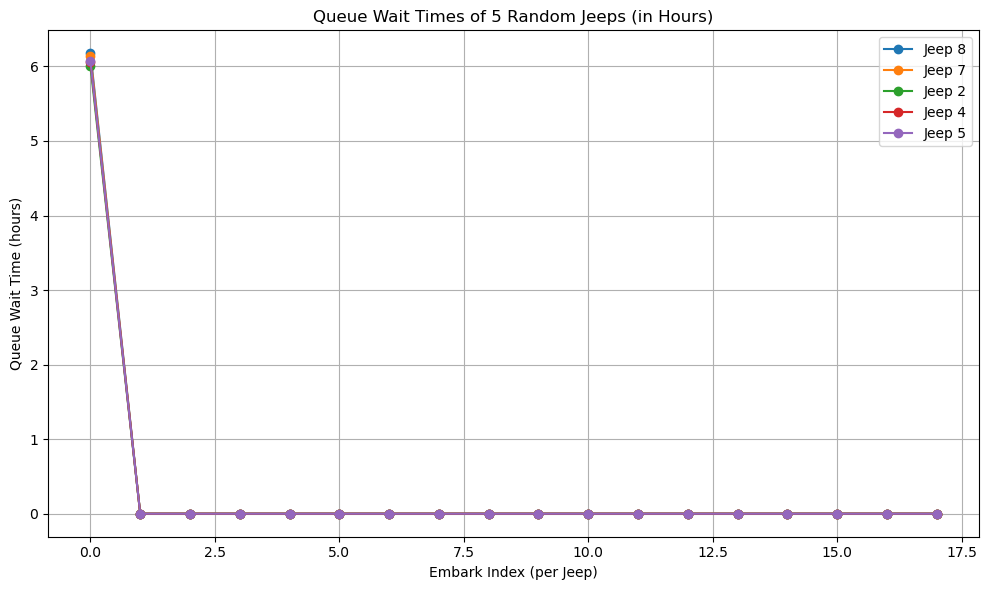

In [31]:
import random

# Randomly select 5 jeep indices
random_indices = random.sample(range(len(jeep_df)), 5)

# Plot each selected jeep's queue wait times (converted to hours)
plt.figure(figsize=(10, 6))
for idx in random_indices:
    wait_times_sec = jeep_df.loc[idx, "queue_wait_times"]
    wait_times_hr = [t / 3600 for t in wait_times_sec]  # Convert to hours
    plt.plot(range(len(wait_times_hr)), wait_times_hr, marker='o', label=f"Jeep {idx}")

plt.xlabel("Embark Index (per Jeep)")
plt.ylabel("Queue Wait Time (hours)")
plt.title("Queue Wait Times of 5 Random Jeeps (in Hours)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
jeep_df["embark_hours"] = jeep_df["embark_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["embark_hours"]

0    [3.23, 6.25, 8.1, 9.57, 10.69, 11.8, 12.57, 13...
1    [2.93, 6.24, 8.09, 9.57, 10.68, 11.79, 12.56, ...
2    [6.01, 7.86, 9.43, 10.54, 11.65, 12.47, 13.17,...
3    [6.02, 7.87, 9.43, 10.55, 11.66, 12.48, 13.18,...
4    [6.07, 7.92, 9.46, 10.57, 11.69, 12.5, 13.19, ...
5    [6.07, 7.92, 9.46, 10.57, 11.69, 12.5, 13.19, ...
6    [6.12, 7.97, 9.49, 10.61, 11.72, 12.52, 13.21,...
7    [6.14, 7.99, 9.5, 10.62, 11.73, 12.52, 13.22, ...
8    [6.18, 8.03, 9.53, 10.64, 11.75, 12.54, 13.23,...
9    [6.18, 8.03, 9.53, 10.64, 11.75, 12.54, 13.24,...
Name: embark_hours, dtype: object

In [33]:
jeep_df["arrive_hours"] = jeep_df["arrive_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["arrive_hours"]

0    [3.78, 8.1, 9.57, 10.69, 11.8, 12.57, 13.26, 1...
1    [3.48, 8.09, 9.57, 10.68, 11.79, 12.56, 13.26,...
2    [7.86, 9.43, 10.54, 11.65, 12.47, 13.17, 13.86...
3    [7.87, 9.43, 10.55, 11.66, 12.48, 13.17, 13.87...
4    [7.92, 9.46, 10.57, 11.68, 12.5, 13.19, 13.89,...
5    [7.92, 9.46, 10.57, 11.69, 12.5, 13.19, 13.89,...
6    [7.97, 9.49, 10.61, 11.72, 12.52, 13.21, 13.91...
7    [7.99, 9.5, 10.62, 11.73, 12.52, 13.22, 13.91,...
8    [8.03, 9.53, 10.64, 11.75, 12.54, 13.23, 13.93...
9    [8.03, 9.53, 10.64, 11.75, 12.54, 13.23, 13.93...
Name: arrive_hours, dtype: object

In [34]:
jeep_df["gross_profit"] = jeep_df["passenger_served"] * 13

jeep_df["gross_profit"]

0    5200
1    5200
2    4940
3    4940
4    4940
5    4940
6    4940
7    4940
8    4940
9    4940
Name: gross_profit, dtype: int64

In [35]:
route_distance = 5 #change if needed
gas_price = 60
liters_per_km = 0.181818
jeep_df["gas_expense"] = len(jeep_df["embark_times"]) * route_distance * liters_per_km * gas_price

In [36]:
jeep_df["gas_expense"]

0    545.454
1    545.454
2    545.454
3    545.454
4    545.454
5    545.454
6    545.454
7    545.454
8    545.454
9    545.454
Name: gas_expense, dtype: float64

In [37]:
jeep_df["net_profit"] = jeep_df["gross_profit"] - jeep_df["gas_expense"]

In [38]:
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times,queue_start_times,queue_wait_times,embark_hours,arrive_hours,gross_profit,gas_expense,net_profit
0,0,20,2,0.42040,0.0025,400,3760|3762|3764|3768|3770|3771|3773|3774|3775|3...,"[13621, 29174, 34465, 38466, 42467, 45242, 477...","[11621, 22508, 29175, 34466, 38467, 42468, 452...","[0, 13621, 29174, 34465, 38466, 42467, 45242, ...","[11621, 8887, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[3.23, 6.25, 8.1, 9.57, 10.69, 11.8, 12.57, 13...","[3.78, 8.1, 9.57, 10.69, 11.8, 12.57, 13.26, 1...",5200,545.454,4654.546
1,1,20,3,0.58455,0.0025,400,3836|3837|3839|3841|3842|3845|3847|3848|3851|3...,"[12543, 29140, 34444, 38445, 42446, 45229, 477...","[10543, 22474, 29141, 34445, 38446, 42447, 452...","[0, 12543, 29140, 34444, 38445, 42446, 45229, ...","[10543, 9931, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[2.93, 6.24, 8.09, 9.57, 10.68, 11.79, 12.56, ...","[3.48, 8.09, 9.57, 10.68, 11.79, 12.56, 13.26,...",5200,545.454,4654.546
2,2,20,3,0.71235,0.0025,380,3674|3678|3680|3681|3684|3686|3687|3692|3694|3...,"[28286, 33932, 37933, 41934, 44909, 47410, 499...","[21620, 28287, 33933, 37934, 41935, 44910, 474...","[0, 28286, 33932, 37933, 41934, 44909, 47410, ...","[21620, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[6.01, 7.86, 9.43, 10.54, 11.65, 12.47, 13.17,...","[7.86, 9.43, 10.54, 11.65, 12.47, 13.17, 13.86...",4940,545.454,4394.546
3,3,20,2,0.29530,0.0025,380,3598|3603|3605|3607|3608|3609|3610|3612|3613|3...,"[28338, 33963, 37964, 41965, 44928, 47429, 499...","[21672, 28339, 33964, 37965, 41966, 44929, 474...","[0, 28338, 33963, 37964, 41965, 44928, 47429, ...","[21672, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[6.02, 7.87, 9.43, 10.55, 11.66, 12.48, 13.18,...","[7.87, 9.43, 10.55, 11.66, 12.48, 13.17, 13.87...",4940,545.454,4394.546
4,4,20,3,0.67950,0.0025,380,3724|3727|3730|3732|3733|3734|3735|3736|3737|3...,"[28504, 34063, 38064, 42065, 44991, 47492, 499...","[21838, 28505, 34064, 38065, 42066, 44992, 474...","[0, 28504, 34063, 38064, 42065, 44991, 47492, ...","[21838, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[6.07, 7.92, 9.46, 10.57, 11.69, 12.5, 13.19, ...","[7.92, 9.46, 10.57, 11.68, 12.5, 13.19, 13.89,...",4940,545.454,4394.546
5,5,20,2,0.32140,0.0025,380,3639|3641|3642|3644|3645|3647|3648|3652|3654|3...,"[28511, 34067, 38068, 42069, 44993, 47494, 499...","[21845, 28512, 34068, 38069, 42070, 44994, 474...","[0, 28511, 34067, 38068, 42069, 44993, 47494, ...","[21845, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[6.07, 7.92, 9.46, 10.57, 11.69, 12.5, 13.19, ...","[7.92, 9.46, 10.57, 11.69, 12.5, 13.19, 13.89,...",4940,545.454,4394.546
6,6,20,3,0.65025,0.0025,380,3761|3763|3765|3766|3767|3769|3772|3776|3780|3...,"[28700, 34180, 38181, 42182, 45064, 47565, 500...","[22034, 28701, 34181, 38182, 42183, 45065, 475...","[0, 28700, 34180, 38181, 42182, 45064, 47565, ...","[22034, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[6.12, 7.97, 9.49, 10.61, 11.72, 12.52, 13.21,...","[7.97, 9.49, 10.61, 11.72, 12.52, 13.21, 13.91...",4940,545.454,4394.546
7,7,20,2,0.35830,0.0025,380,3685|3688|3689|3690|3691|3693|3696|3697|3698|3...,"[28758, 34215, 38216, 42217, 45086, 47587, 500...","[22092, 28759, 34216, 38217, 42218, 45087, 475...","[0, 28758, 34215, 38216, 42217, 45086, 47587, ...","[22092, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[6.14, 7.99, 9.5, 10.62, 11.73, 12.52, 13.22, ...","[7.99, 9.5, 10.62, 11.73, 12.52, 13.22, 13.91,...",4940,545.454,4394.546
8,8,20,3,0.62100,0.0025,380,3803|3806|3809|3810|3811|3812|3813|3815|3816|3...,"[28898, 34299, 38300, 42301, 45138, 47639, 501...","[22232, 28899, 34300, 38301, 42302, 45139, 476...","[0, 28898, 34299, 38300, 42301, 45138, 47639, ...","[22232, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[6.18, 8.03, 9.53, 10.64, 11.75, 12.54, 13.23,...","[8.03, 9.53, 10.64, 11.75, 12.54, 13.23, 13.93...",4940,545.454,4394.546
9,9,20,2,0.38170,0.0025,380,3720|3721|3722|3723|3725|3726|3728|3729|3731|3...,"[28916, 34310,

In [39]:
passenger_df = pd.read_csv("export_passenger_pool.csv")

passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]] = passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]].apply(lambda times: [round(int(t) / 3600, 2) for t in times] )

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal
0,0,0.04,0.04,3.23,3.78,0,0
1,1,0.06,0.06,2.93,3.48,1,1
2,2,0.17,0.17,2.93,3.48,1,1
3,3,0.47,0.47,3.23,3.78,0,0
4,4,0.50,0.50,2.93,3.48,1,1
...,...,...,...,...,...,...,...
4422,4422,23.79,0.00,0.00,0.00,-1,0
4423,4423,23.84,0.00,0.00,0.00,-1,1
4424,4424,23.88,0.00,0.00,0.00,-1,0
4425,4425,23.95,0.00,0.00,0.00,-1,1


In [40]:
passenger_df["turn_around_time"] = passenger_df["destination_arrival_time"] - passenger_df["terminal_arrival_time"]

passenger_df = passenger_df[passenger_df["turn_around_time"] > 0]

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.04,0.04,3.23,3.78,0,0,3.74
1,1,0.06,0.06,2.93,3.48,1,1,3.42
2,2,0.17,0.17,2.93,3.48,1,1,3.31
3,3,0.47,0.47,3.23,3.78,0,0,3.31
4,4,0.50,0.50,2.93,3.48,1,1,2.98
...,...,...,...,...,...,...,...,...
3667,3667,18.90,23.02,23.02,23.64,0,0,4.74
3668,3668,18.90,23.02,23.02,23.64,0,0,4.74
3671,3671,18.90,23.02,23.02,23.64,0,0,4.74
3672,3672,18.90,23.02,23.02,23.64,0,0,4.74


In [41]:
terminal_0_df = passenger_df[passenger_df["terminal"] == 0]
terminal_1_df = passenger_df[passenger_df["terminal"] == 1]


In [42]:
terminal_0_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.04,0.04,3.23,3.78,0,0,3.74
3,3,0.47,0.47,3.23,3.78,0,0,3.31
5,5,0.52,0.52,3.23,3.78,0,0,3.26
9,9,0.86,0.86,3.23,3.78,0,0,2.92
11,11,1.03,1.03,3.23,3.78,0,0,2.75
...,...,...,...,...,...,...,...,...
3667,3667,18.90,23.02,23.02,23.64,0,0,4.74
3668,3668,18.90,23.02,23.02,23.64,0,0,4.74
3671,3671,18.90,23.02,23.02,23.64,0,0,4.74
3672,3672,18.90,23.02,23.02,23.64,0,0,4.74


In [43]:
terminal_1_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
1,1,0.06,0.06,2.93,3.48,1,1,3.42
2,2,0.17,0.17,2.93,3.48,1,1,3.31
4,4,0.50,0.50,2.93,3.48,1,1,2.98
6,6,0.64,0.64,2.93,3.48,1,1,2.84
7,7,0.69,0.69,2.93,3.48,1,1,2.79
...,...,...,...,...,...,...,...,...
3589,3589,18.77,23.02,23.02,23.64,1,1,4.87
3591,3591,18.78,23.02,23.02,23.64,1,1,4.86
3592,3592,18.78,23.02,23.02,23.64,1,1,4.86
3593,3593,18.78,23.02,23.02,23.64,1,1,4.86


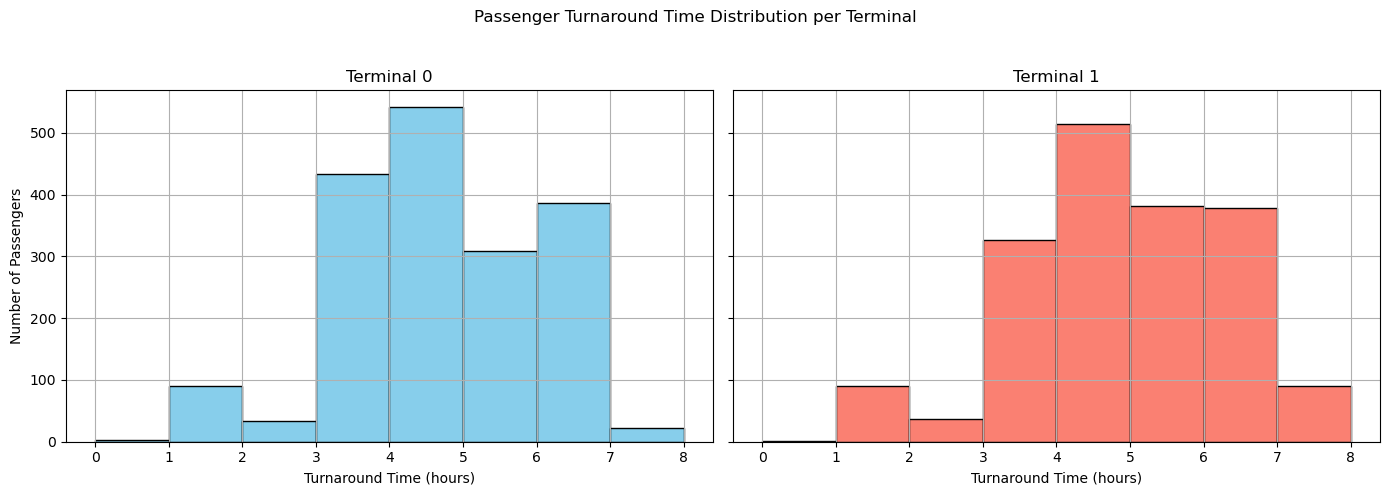

In [44]:

# Define bins (hourly intervals)
max_turnaround = max(terminal_0_df["turn_around_time"].max(), terminal_1_df["turn_around_time"].max())
bins = range(0, int(max_turnaround) + 2)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Terminal 0 histogram
axs[0].hist(terminal_0_df["turn_around_time"], bins=bins, color='skyblue', edgecolor='black')
axs[0].set_title("Terminal 0")
axs[0].set_xlabel("Turnaround Time (hours)")
axs[0].set_ylabel("Number of Passengers")
axs[0].grid(True)

# Terminal 1 histogram
axs[1].hist(terminal_1_df["turn_around_time"], bins=bins, color='salmon', edgecolor='black')
axs[1].set_title("Terminal 1")
axs[1].set_xlabel("Turnaround Time (hours)")
axs[1].grid(True)

plt.suptitle("Passenger Turnaround Time Distribution per Terminal")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

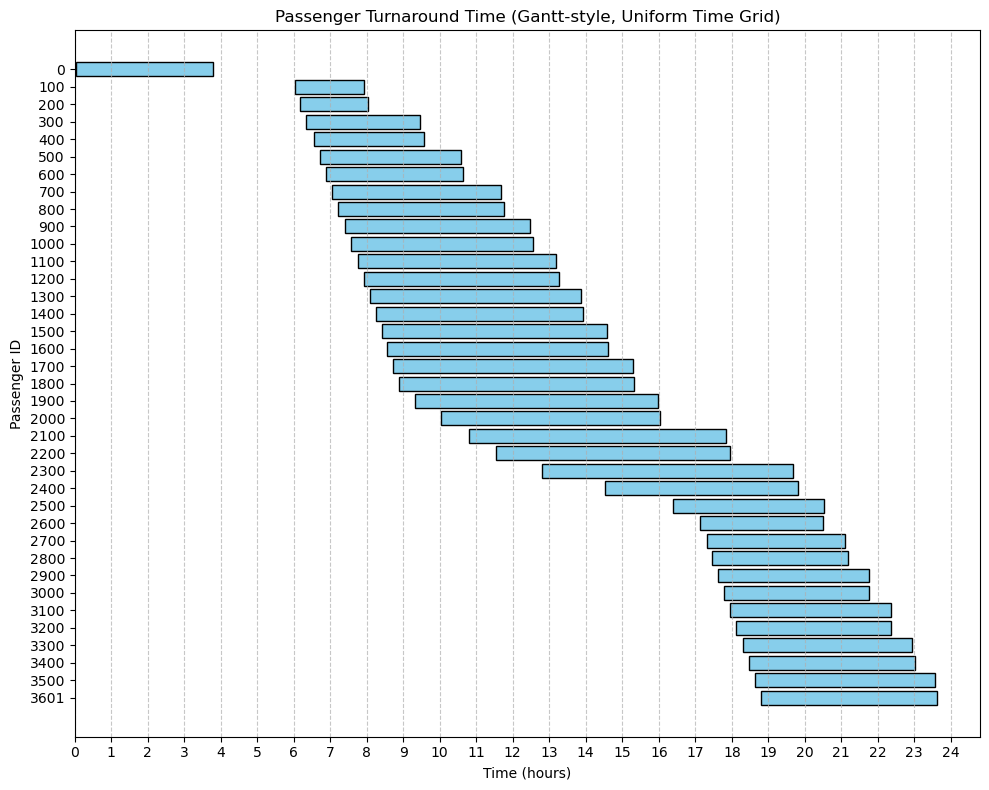

In [45]:

sample_df = passenger_df.iloc[::100].copy()

# Sample by index increments (e.g., every 100th row)
sample_df = passenger_df.iloc[::100].copy()

# Prepare data
starts = sample_df["terminal_arrival_time"]
durations = sample_df["turn_around_time"]
passenger_ids = sample_df["passenger_id"].astype(str)

# Set figure
plt.figure(figsize=(10, 8))
plt.barh(passenger_ids, durations, left=starts, color='skyblue', edgecolor='black')

# Set x-axis gridlines and ticks at every 1 hour
xmin = int(sample_df["terminal_arrival_time"].min())
xmax = int(sample_df["destination_arrival_time"].max()) + 1
plt.xticks(np.arange(xmin, xmax + 1, 1))  # every 1 hour
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Labels and layout
plt.xlabel("Time (hours)")
plt.ylabel("Passenger ID")
plt.title("Passenger Turnaround Time (Gantt-style, Uniform Time Grid)")
plt.tight_layout()
plt.gca().invert_yaxis()

plt.show()

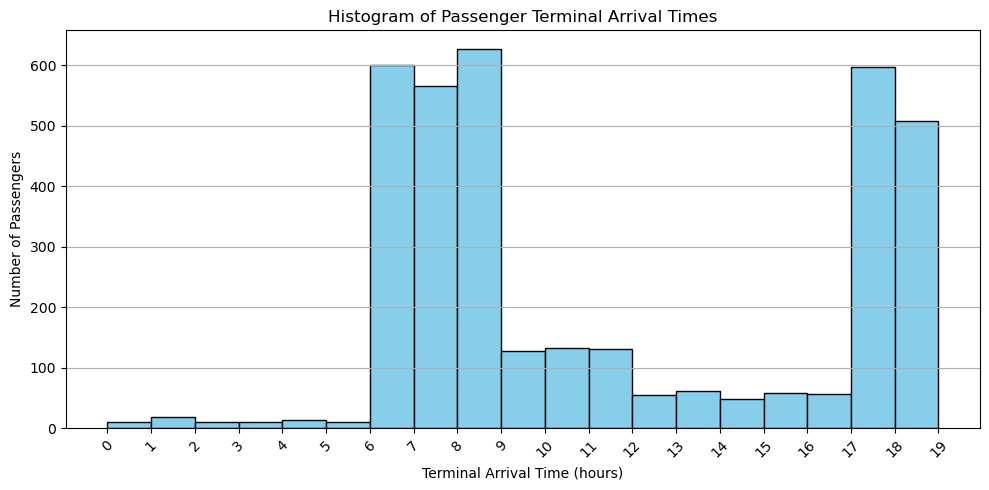

In [46]:
# Define bins: from min to max time, 1-hour step
min_time = int(passenger_df["terminal_arrival_time"].min())
max_time = int(passenger_df["terminal_arrival_time"].max()) + 1
bins = np.arange(min_time, max_time + 1, 1)  # 1-hour bins

# Plot
plt.figure(figsize=(10, 5))
plt.hist(passenger_df["terminal_arrival_time"], bins=bins, color='skyblue', edgecolor='black')

# Labels and styling
plt.xlabel("Terminal Arrival Time (hours)")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Passenger Terminal Arrival Times")
plt.grid(True, axis='y')
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()